In [136]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, SymLogNorm
from matplotlib.ticker import MaxNLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pop_tools

In [137]:
import glob

from analysis import (
    open_approx_flux_map,
    open_true_flux_map,
    open_deficit_tracer_experiment,
    deficit_tracer_experiment_paths,
    open_true_curve,
    open_deficit_tracer_curve,
    to_instantaneous,
    MODES,
)

In [138]:
def _auto_symlog_norm(data_min, data_max, log_decades=2, symmetric=False):
    """
    Automatically choose a SymLogNorm spanning [data_min, data_max], with
    linthresh set `log_decades` decades below the largest-magnitude value.
    Mirrors the auto log-scale approach in
    DeficitTracer/experiments/pacific/deltaDIC_deltaALK.ipynb.

    If `symmetric`, the norm spans [-abs_max, abs_max]; otherwise it's
    one-sided, following whichever sign (positive/negative) dominates the
    data (matching a `vmin=0` linear scale for mostly-positive data).
    """
    abs_max = max(abs(data_min), abs(data_max))
    if abs_max == 0:
        abs_max = 1.0
    linthresh = 10 ** max(-10, np.floor(np.log10(abs_max)) - log_decades)

    if symmetric:
        return SymLogNorm(linthresh=linthresh, vmin=-abs_max, vmax=abs_max)
    if abs(data_min) > abs(data_max):
        return SymLogNorm(linthresh=linthresh, vmin=data_min, vmax=0)
    return SymLogNorm(linthresh=linthresh, vmin=0, vmax=data_max)


def _sci_label(value, name):
    """'Name $= +1.23 \\times 10^{4}$', in the style of deltaDIC_deltaALK.ipynb's get_label_string."""
    base, exponent = f"{value:+.2e}".split("e")
    return rf"{name} $= {base} \times 10^{{{int(exponent)}}}$"

In [139]:
def _get_polygon_mask(suffix, mode, polygon_id):
    """Boolean mask of grid cells belonging to `polygon_id`, derived from
    the initial forcing field of the deficit-tracer experiment (mirrors
    `_plot_polygons` in validation_curves_all.ipynb)."""
    ds = open_deficit_tracer_experiment(suffix=suffix, first_file=True)
    forcing_varname = "DELTADIC" if mode == "dor" else "DELTAALK"
    return ds[f"{forcing_varname}{polygon_id}_FORCING"].isel(time=0) > 0

In [140]:
import calendar

# Real calendar date of the injection month (POP history stamp "0347-01").
_INJECTION_YM = (1999, 1)


def _months_since_injection(stamp, ref_stamp):
    """Whole months from the injection month to `stamp` (0 = injection month).

    Both arguments are "YYYY-MM" POP history stamps; `ref_stamp` is the
    injection month (the first history file of the deficit-tracer run).
    """
    (y0, m0), (y1, m1) = (
        tuple(int(x) for x in s.split("-")) for s in (ref_stamp, stamp)
    )
    return (y1 - y0) * 12 + (m1 - m0)


def _elapsed_month_label(n):
    """e.g. `n=10` -> '+10 months (Nov 1999)'."""
    y, m = _INJECTION_YM
    total = y * 12 + (m - 1) + n
    unit = "month" if n == 1 else "months"
    return f"+{n} {unit} ({calendar.month_abbr[total % 12 + 1]} {total // 12})"


def _month_flux_maps(suffix, mode, polygon_id, month):
    """This single month's air-sea CO2 flux (mmol m^-2), truth and deficit-tracer
    approximation, read live from the monthly history files.

    month : int file index (0 = injection month, Jan 1999; negatives count from
            the end) or a "YYYY-MM" POP stamp string.
    Returns (true_flux, approx_flux, stamp, n_months), where `n_months` is the
    number of months after injection (0 = injection month, Jan 1999).
    """
    _, dpath = deficit_tracer_experiment_paths(suffix)
    dfiles = sorted(glob.glob(dpath))
    _, tpath = MODES[mode](str(polygon_id))
    tfiles = sorted(glob.glob(tpath))

    def _stamp(f):
        return f.split(".pop.h.")[-1][:-3]

    if isinstance(month, str):
        idx = next(i for i, f in enumerate(dfiles) if _stamp(f) == month)
    else:
        idx = month if month >= 0 else len(dfiles) + month
    stamp = _stamp(dfiles[idx])
    # look up truth file by stamp — lists may differ in length
    try:
        tidx = next(i for i, f in enumerate(tfiles) if _stamp(f) == stamp)
    except StopIteration:
        raise ValueError(f"No truth file found for stamp {stamp}")
    n_months = _months_since_injection(stamp, _stamp(dfiles[0]))

    dds = xr.open_dataset(dfiles[idx], decode_timedelta=False)
    tb = np.ravel(dds["time_bound"].values)
    dt = (tb[1] - tb[0]).total_seconds()                        # seconds in the month

    def _sq(da):
        return da.isel({d: 0 for d in da.dims if da.sizes[d] == 1})

    # same construction as integrate_flux_map.py / integrate_true_flux_map.py,
    # just without the cumulative sum
    approx = _sq(dds[f"STF_DELTADIC{polygon_id}"] - dds[f"DELTADIC{polygon_id}_FORCING"])
    approx = approx * dt / 100.0
    if mode == "dor":
        approx = -approx

    tds = xr.open_dataset(tfiles[tidx], decode_timedelta=False)
    true = _sq(tds["FG_CO2"] - tds["FG_ALT_CO2"]) * dt / 100.0

    return true.compute(), approx.compute(), stamp, n_months


def _zoom_extent(mask, grid, zoom):
    "Compute a cartopy extent from a polygon mask and zoom margin."
    pad = 20.0 if zoom is True else float(zoom)
    m = np.asarray(mask.values, dtype=bool)
    flon = np.asarray(grid.TLONG.values)[m].astype(float)
    flat = np.asarray(grid.TLAT.values)[m].astype(float)
    flon = np.where(flon > 180, flon - 360, flon)
    if flon.size and flon.max() - flon.min() > 180:
        flon = np.where(flon < 0, flon + 360, flon)
    return [flon.min() - pad, flon.max() + pad,
            max(flat.min() - pad, -90), min(flat.max() + pad, 90)]


def _in_extent(tlong, tlat, extent):
    "Boolean mask of grid cells inside `extent`."
    lon_norm = np.where(tlong > 180, tlong - 360, tlong)
    return ((lon_norm >= extent[0]) & (lon_norm <= extent[1]) &
            (tlat >= extent[2]) & (tlat <= extent[3]))


def compare_air_sea_flux(suffix, mode, polygon_id, field_max=None, diff_max=None,
                         zoom=None, extent=None, month=None,
                         log=None, log_decades=None, panel_labels=("a", "b"),
                         n_months=None, ncol=4):
    """
    Air-sea CO2 flux for a polygon:

        left  : truth  (CESM/MARBL)
        right : error  = truth - approximate (deficit tracer)

    month : `None` -> the 15-yr *cumulative* flux, from the precomputed maps
            (`integrate_true_flux_map.py` / `integrate_flux_map.py`).
            Otherwise a single month, read live from the monthly history files:
            an int file index (0 = injection month, Jan 1999; negatives count
            from the end) or a "YYYY-MM" POP stamp string. The panel titles
            then show months-after-injection and the calendar month, e.g.
            "[+10 months (Nov 1999)]".

    Both panels use a linear colour scale. Each colourbar grows an extension
    triangle only on the side(s) where the data actually spills past the limit.

    field_max : truth panel upper limit (lower limit is always 0).
                `None` -> data max.
    diff_max  : error panel is symmetric about 0 at +/- diff_max.
                `None` -> the data's largest magnitude.
    zoom      : `None` -> global; `True` -> zoom to the polygon footprint with a
                20 deg margin; a number -> same, with that many degrees of margin.
    extent    : `(lon_min, lon_max, lat_min, lat_max)` to set the view
                explicitly (overrides `zoom`).
    n_months  : when set, shows the first `n_months` months as a diff-only
                small-multiples grid (ignores `month`).  `ncol` sets the number
                of columns (default 4).  The colour scale is shared across all
                panels and based on the visible region when zoom/extent is active.

    `log` / `log_decades` are accepted for backward compatibility and ignored.
    """
    grid = pop_tools.get_grid("POP_gx1v7")
    mask = _get_polygon_mask(suffix, mode, polygon_id)

    # resolve extent from zoom once, shared by both paths
    if extent is None and zoom:
        extent = _zoom_extent(mask, grid, zoom)

    # --- small-multiples diff grid ---
    if n_months is not None:
        diffs, labels = [], []
        for k in range(n_months):
            tf, af, _stamp, n_mo = _month_flux_maps(suffix, mode, polygon_id, k)
            diffs.append(af - tf)
            labels.append(_elapsed_month_label(n_mo))

        if diff_max is None:
            if extent is not None:
                in_view = _in_extent(grid.TLONG.values, grid.TLAT.values, extent)
                vals = np.concatenate([d.values[in_view] for d in diffs])
            else:
                vals = np.concatenate([d.values.ravel() for d in diffs])
            diff_max = float(np.nanmax(np.abs(vals)))

        nrow = int(np.ceil(n_months / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4 * nrow),
                                 squeeze=False,
                                 subplot_kw={"projection": ccrs.PlateCarree()})
        pm = None
        exp_id = rf"{polygon_id}\!\ominus" if mode == "dor" else rf"{polygon_id}\!\oplus"
        for k in range(nrow * ncol):
            ax = axes.flat[k]
            if k >= n_months:
                ax.axis("off")
                continue
            pm = ax.pcolormesh(grid.TLONG, grid.TLAT, diffs[k],
                               transform=ccrs.PlateCarree(),
                               cmap="RdBu_r", vmin=-diff_max, vmax=diff_max)
            _add_coastlines_and_gridlines(ax)
            ax.contour(grid.TLONG, grid.TLAT, mask,
                       levels=[0.5], colors="black", linewidths=1.2,
                       transform=ccrs.PlateCarree())
            if extent is None:
                ax.set_global()
            else:
                ax.set_extent(extent, crs=ccrs.PlateCarree())
            ax.set_title(labels[k], fontsize=9)
        fig.colorbar(pm, ax=list(axes.flat), orientation="horizontal", pad=0.03,
                     shrink=0.5, label=r"$\delta \tilde{F}_{\text{CO}_2} - \delta F_{\text{CO}_2}$  [mmol m$^{-2}$]",
                     ticks=MaxNLocator(nbins=5))
        fig.suptitle(rf"$P{exp_id}$  ({suffix})  — error: first {n_months} months")
        return fig

    # --- single panel or cumulative ---
    if month is None:
        true_flux = open_true_flux_map(polygon_id, mode).squeeze(drop=True) / 100   # mmol/m^3 cm -> mmol/m^2
        approx_flux = open_approx_flux_map(polygon_id, suffix).squeeze(drop=True) / 100
        n_months_label = None
    else:
        true_flux, approx_flux, _stamp, n_months_label = _month_flux_maps(suffix, mode, polygon_id, month)
    diff = approx_flux - true_flux

    if field_max is None:
        field_max = max(float(true_flux.max()), float(approx_flux.max()))
    if diff_max is None:
        diff_max = float(max(abs(diff.min()), abs(diff.max())))

    # only extend a colourbar where the data really exceeds the limit
    field_ext = "max" if float(true_flux.max()) > field_max else "neither"
    d_lo, d_hi = float(diff.min()) < -diff_max, float(diff.max()) > diff_max
    diff_ext = "both" if d_lo and d_hi else "min" if d_lo else "max" if d_hi else "neither"

    fig, axs = plt.subplots(
        1, 2, figsize=(13, 5), subplot_kw={"projection": ccrs.PlateCarree()}
    )

    p0 = axs[0].pcolormesh(
        grid.TLONG, grid.TLAT, true_flux, transform=ccrs.PlateCarree(),
        cmap="PuRd", vmin=0, vmax=field_max,
    )
    p1 = axs[1].pcolormesh(
        grid.TLONG, grid.TLAT, diff, transform=ccrs.PlateCarree(),
        cmap="RdBu_r", vmin=-diff_max, vmax=diff_max,
    )

    for ax, p, ext in zip(axs, [p0, p1], [field_ext, diff_ext]):
        cbar = fig.colorbar(
            p, ax=ax, label=r"mmol m$^{-2}$", shrink=0.75,
            orientation="horizontal", pad=0.12, extend=ext,
            ticks=MaxNLocator(nbins=5),
        )
        cbar.ax.tick_params(labelsize=10)
        _add_coastlines_and_gridlines(ax)
        ax.contour(
            grid.TLONG, grid.TLAT, mask,
            levels=[0.5], colors="black", linewidths=1.2,
            transform=ccrs.PlateCarree(),
        )

    for ax in axs:
        if extent is None:
            ax.set_global()
        else:
            ax.set_extent(extent, crs=ccrs.PlateCarree())

    if month is None:
        sym_true = r"\int \delta F_{\text{CO}_2}\, dt"
        sym_approx = r"\int \delta \tilde{F}_{\text{CO}_2}\, dt"
        when = ""
    else:
        sym_true = r"\delta F_{\text{CO}_2}"
        sym_approx = r"\delta \tilde{F}_{\text{CO}_2}"
        when = f"  [{_elapsed_month_label(n_months_label)}]"
    exp_id = rf"{polygon_id}\!\ominus" if mode == "dor" else rf"{polygon_id}\!\oplus"

    axs[0].set_title(f"({panel_labels[0]}) $P{exp_id}$: ${sym_true}$ {when}")
    axs[1].set_title(f"({panel_labels[1]}) $P{exp_id}$: ${sym_approx} - {sym_true}$ {when}")

    box = dict(facecolor="white", alpha=0.7, edgecolor="none")
    if not zoom:
        axs[0].text(0.6, 0.8, _sci_label(float(true_flux.max()), "Max"),
                    transform=axs[0].transAxes, ha="left", va="center", bbox=box)
        axs[1].text(0.6, 0.8, _sci_label(float(diff.max()), "Max"),
                    transform=axs[1].transAxes, ha="left", va="center", bbox=box)
        axs[1].text(0.6, 0.7, _sci_label(float(diff.min()), "Min"),
                    transform=axs[1].transAxes, ha="left", va="center", bbox=box)

    return fig

In [141]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

In [142]:
_MOL_TO_KT = 4.4e-8  # mol CO2 -> ktCO2: 44 g/mol * 1e-9 kt/g


def plot_flux_summary(polygon_id, mode, suffix, zoom=True, field_max=None, diff_max=None):
    """
    2×2 figure for one polygon:
      [0,0]  instantaneous uptake timeseries (truth + CDR tracer)
      [0,1]  instantaneous uptake error      (CDR tracer − truth)
      [1,0]  cumulative air-sea flux map     (truth)
      [1,1]  cumulative air-sea flux error   (truth − approx)

    zoom : True  → zoom to polygon footprint with 20 deg margin
           float → same with that many degrees of margin
           None  → global view
    """
    exp_id = rf"{polygon_id}\!\ominus" if mode == "dor" else rf"{polygon_id}\!\oplus"
    exp_label = rf"$P{exp_id}$"
    
    # --- timeseries ---
    ds_true   = open_true_curve(polygon_id, mode)
    ds_tilde  = open_deficit_tracer_curve(polygon_id, suffix)
    up_true   = to_instantaneous(ds_true.uptake.squeeze()) * _MOL_TO_KT
    up_tracer = to_instantaneous(ds_tilde.uptake) * _MOL_TO_KT
    x_true    = up_true.elapsed_time / 365
    x_tracer  = up_tracer.elapsed_time / 365
    min_len   = min(len(up_true), len(up_tracer))
    diff_ts   = up_tracer.values[:min_len] - up_true.values[:min_len]
    x_diff    = x_true.values[:min_len]

    # --- flux maps ---
    grid        = pop_tools.get_grid("POP_gx1v7")
    mask        = _get_polygon_mask(suffix, mode, polygon_id)
    true_flux   = open_true_flux_map(polygon_id, mode).squeeze(drop=True) / 100
    approx_flux = open_approx_flux_map(polygon_id, suffix).squeeze(drop=True) / 100
    diff_map    = approx_flux - true_flux

    extent = _zoom_extent(mask, grid, zoom) if zoom else None

    if field_max is None:
        field_max = float(true_flux.max())
    if diff_max is None:
        diff_max = float(max(abs(diff_map.min()), abs(diff_map.max())))

    # --- layout: top row = regular axes, bottom row = cartopy axes ---
    fig = plt.figure(figsize=(11, 9))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1, 1.4], hspace=0.38, wspace=0.25)

    ax_ts   = fig.add_subplot(gs[0, 0])
    ax_err  = fig.add_subplot(gs[0, 1])
    ax_map0 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
    ax_map1 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())

    # (a) timeseries
    ax_ts.plot(x_true,   up_true.values,   lw=2,  color="tab:orange", label="Truth")
    ax_ts.plot(x_tracer, up_tracer.values, lw=2, ls="--", color="k", label="CDR tracer")
    ax_ts.axhline(0, color="k", lw=1)
    ax_ts.axvline(1 / 12, color="k", lw=1.5, ls="dotted")
    ax_ts.set_xlabel("Years since intervention")
    ax_ts.set_ylabel(r"ktCO$_2$ month$^{-1}$")
    math = r"$\int\int \delta F_{\mathrm{CO}_2}\,dx\,dy$ vs. $\int\int \delta \tilde{F}_{\mathrm{CO}_2}\,dx\,dy$"
    ax_ts.set_title(f"(a) {exp_label}: {math}")
    ax_ts.legend()
    ax_ts.grid(True, ls="--", lw=0.4, color="gray", alpha=0.5)

    # (b) timeseries difference
    ax_err.plot(x_diff, diff_ts, lw=2)
    ax_err.axhline(0, color="k", lw=1)
    ax_err.axvline(1 / 12, color="k", lw=1.5, ls="dotted")
    ax_err.set_xlabel("Years since intervention")
    ax_err.set_ylabel(r"ktCO$_2$ month$^{-1}$")
    math = r"$\int\int (\delta \tilde{F}_{\mathrm{CO}_2} - \delta F_{\mathrm{CO}_2})\,dx\,dy$"
    ax_err.set_title(f"(b) {exp_label}: {math}")
    ax_err.grid(True, ls="--", lw=0.4, color="gray", alpha=0.5)

    # (c) cumulative flux map — truth
    field_ext = "max" if float(true_flux.max()) > field_max else "neither"
    p0 = ax_map0.pcolormesh(grid.TLONG, grid.TLAT, true_flux,
                             transform=ccrs.PlateCarree(), cmap="PuRd",
                             vmin=0, vmax=field_max)
    fig.colorbar(p0, ax=ax_map0, label=r"mmol m$^{-2}$", shrink=0.75,
                 orientation="horizontal", pad=0.12, extend=field_ext,
                 ticks=MaxNLocator(nbins=5))
    _add_coastlines_and_gridlines(ax_map0)
    ax_map0.contour(grid.TLONG, grid.TLAT, mask, levels=[0.5],
                    colors="black", linewidths=1.2, transform=ccrs.PlateCarree())
    ax_map0.set_extent(extent, crs=ccrs.PlateCarree()) if extent else ax_map0.set_global()
    math = r"$\int \delta F_{\mathrm{CO}_2}\, dt$"
    ax_map0.set_title(f"(c) {exp_label}: {math}")

    # (d) cumulative flux error map
    d_lo, d_hi = float(diff_map.min()) < -diff_max, float(diff_map.max()) > diff_max
    diff_ext   = "both" if d_lo and d_hi else "min" if d_lo else "max" if d_hi else "neither"
    p1 = ax_map1.pcolormesh(grid.TLONG, grid.TLAT, diff_map,
                             transform=ccrs.PlateCarree(), cmap="RdBu_r",
                             vmin=-diff_max, vmax=diff_max)
    fig.colorbar(p1, ax=ax_map1, label=r"mmol m$^{-2}$", shrink=0.75,
                 orientation="horizontal", pad=0.12, extend=diff_ext,
                 ticks=MaxNLocator(nbins=5))
    _add_coastlines_and_gridlines(ax_map1)
    ax_map1.contour(grid.TLONG, grid.TLAT, mask, levels=[0.5],
                    colors="black", linewidths=1.2, transform=ccrs.PlateCarree())
    ax_map1.set_extent(extent, crs=ccrs.PlateCarree()) if extent else ax_map1.set_global()
    math = r"$\int (\delta \tilde{F}_{\mathrm{CO}_2} - \delta F_{\mathrm{CO}_2})\, dt$"
    ax_map1.set_title(f"(d) {exp_label}: {math}")

    fig.savefig(
        f"figures/flux_summary_{polygon_id}_{mode}_{suffix}.png",
        dpi=300,
        bbox_inches="tight",
    )    
    return fig

## Combined timeseries + flux maps

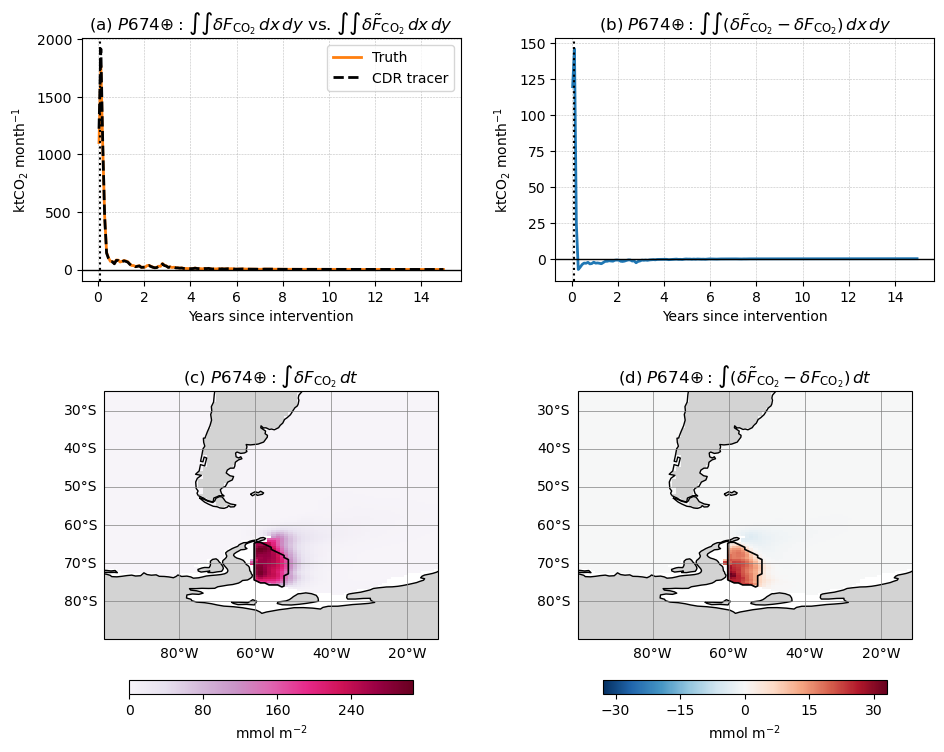

In [121]:
fig = plot_flux_summary("674", mode="oae", suffix="all-oae-daily", zoom=40)

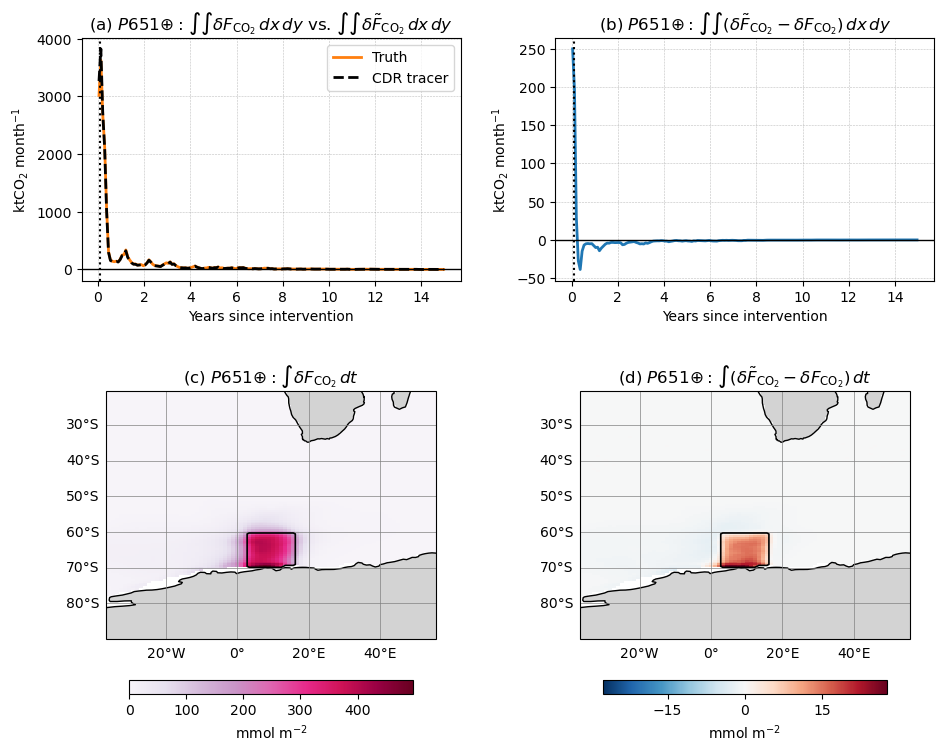

In [118]:
fig = plot_flux_summary("651", mode="oae", suffix="all-oae-daily", zoom=40)

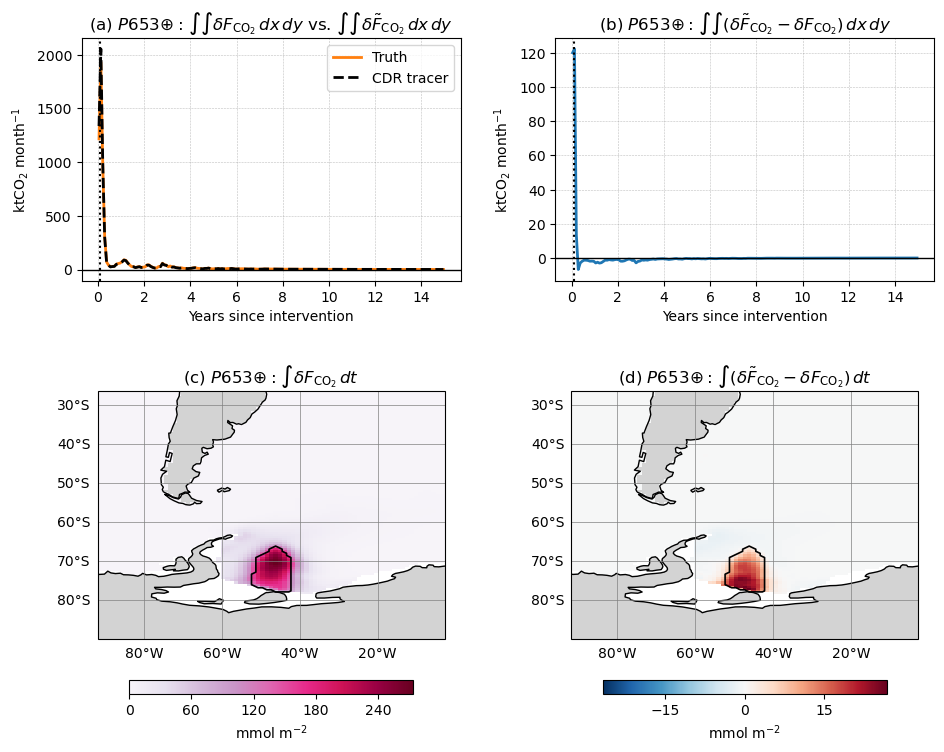

In [119]:
fig = plot_flux_summary("653", mode="oae", suffix="all-oae-daily", zoom=40)

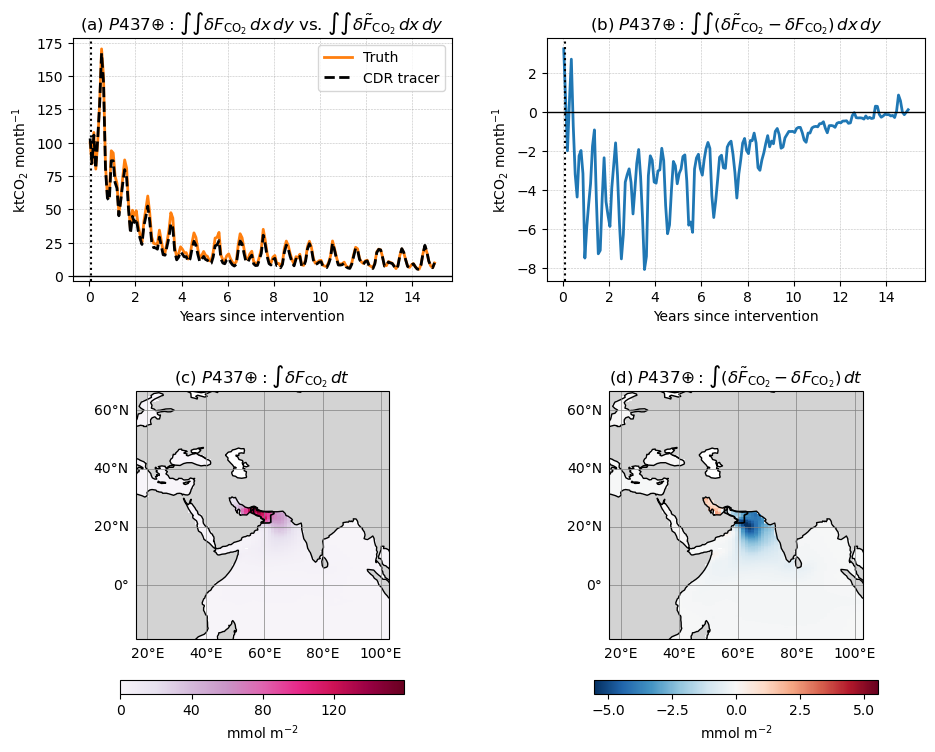

In [120]:
fig = plot_flux_summary("437", mode="oae", suffix="all-oae-daily", zoom=40)

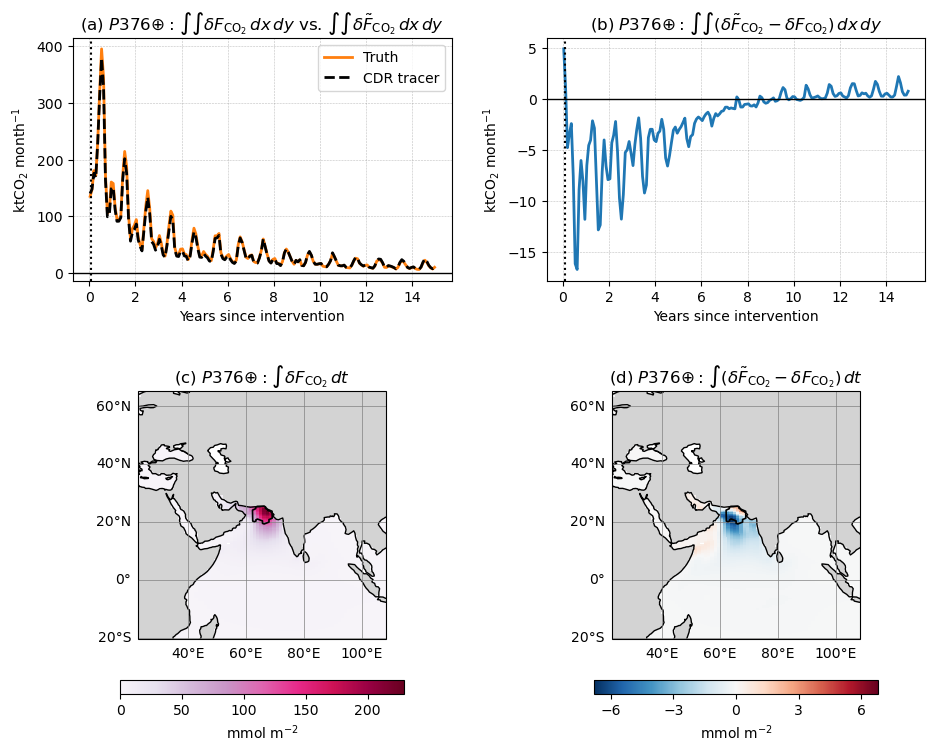

In [144]:
fig = plot_flux_summary("376", mode="oae", suffix="all-oae-daily", zoom=40)

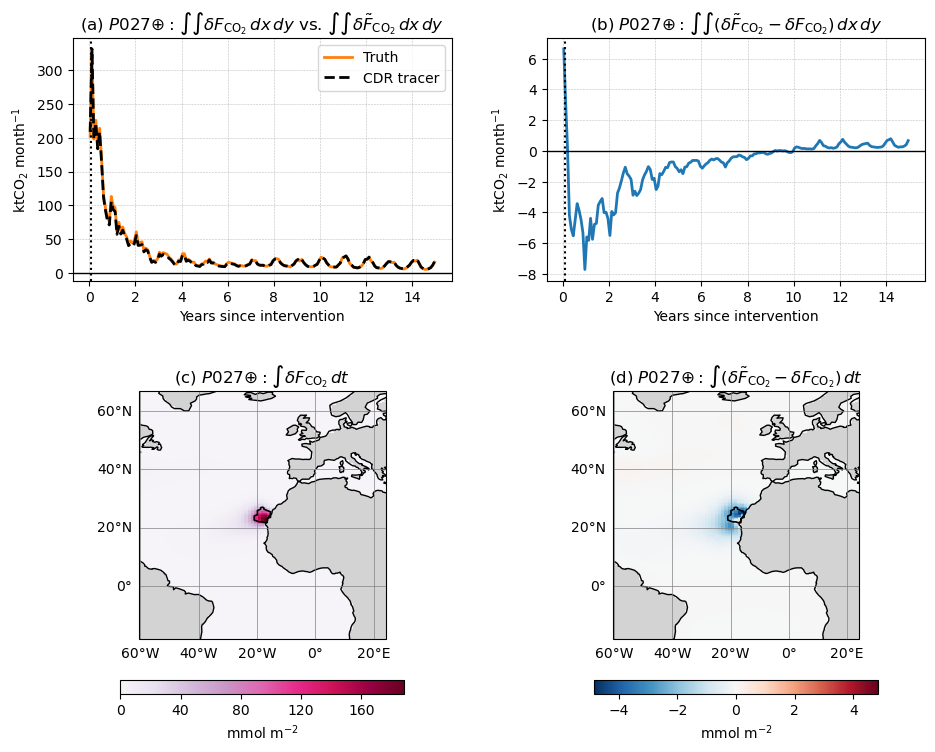

In [145]:
fig = plot_flux_summary("027", mode="oae", suffix="all-oae-daily", zoom=40)

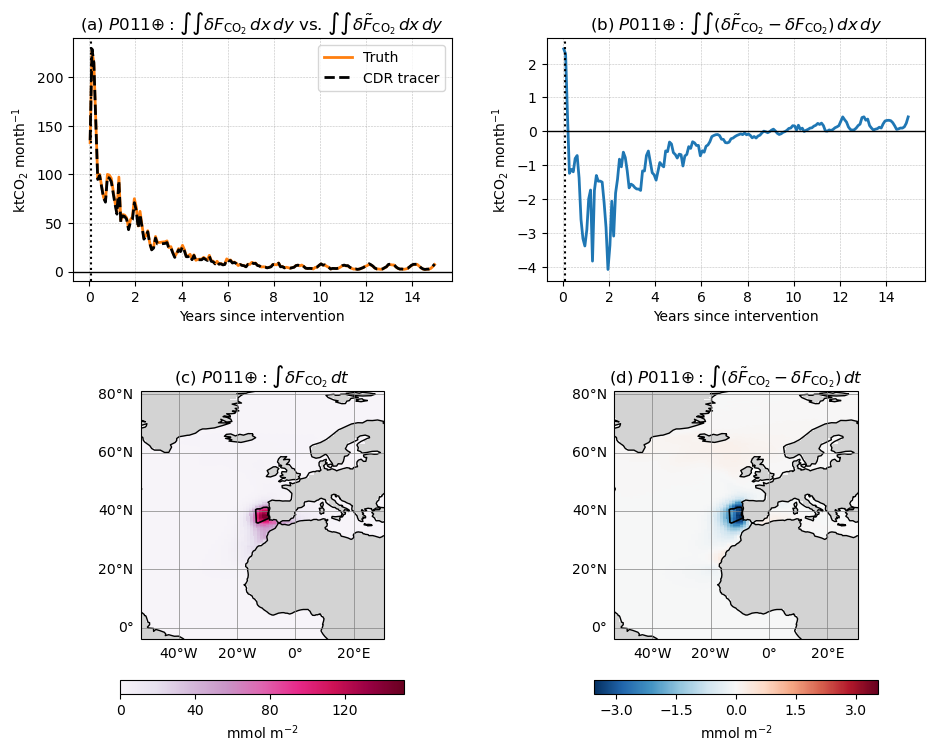

In [146]:
fig = plot_flux_summary("011", mode="oae", suffix="all-oae-daily", zoom=40)

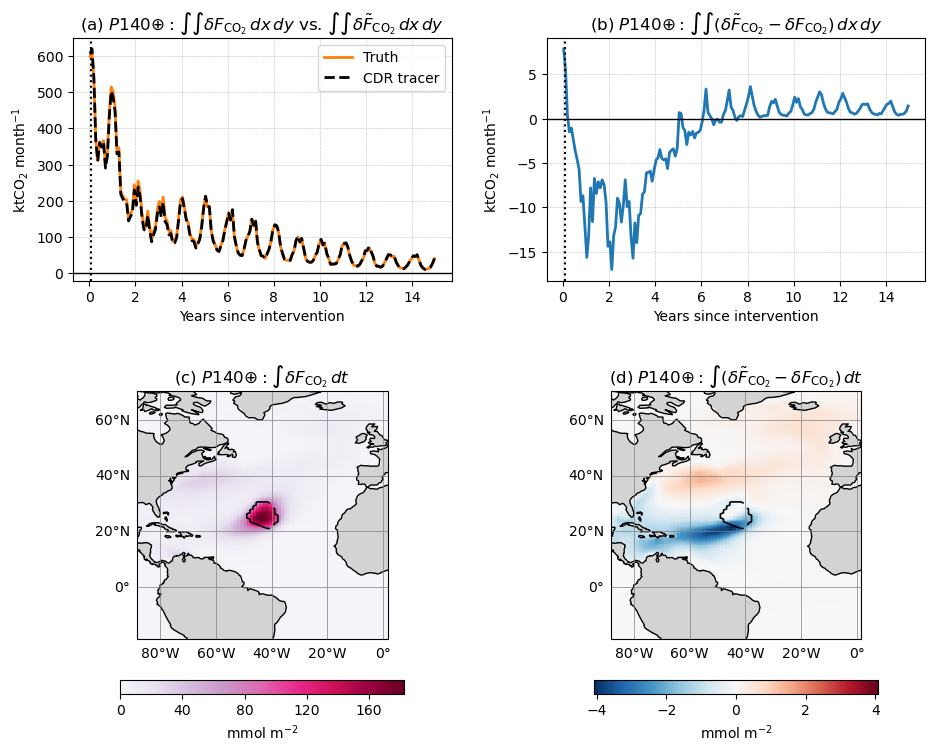

In [147]:
fig = plot_flux_summary("140", mode="oae", suffix="all-oae-daily", zoom=40)